h	max |1 + h*lambda(x)|	stable?
0.01	1.020000		Not fully stable
0.05	1.100000		Not fully stable
0.15	1.300000		Not fully stable
0.20	1.400000		Not fully stable
0.25	1.499999		Not fully stable
0.50	1.999999		Not fully stable
0.75	2.499998		Not fully stable
1.00	2.999998		Not fully stable


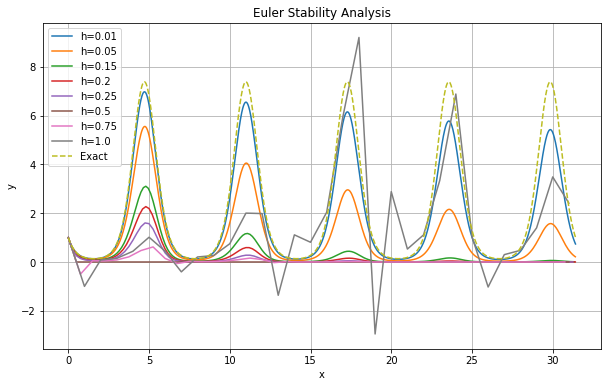

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# lambda(x)
def lam(x):
    return -2 * np.cos(x)

# Euler method
def euler_method(h, x_start=0, x_end=10*np.pi, y0=1):
    num_steps = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_start + num_steps * h, num_steps + 1)
    y = np.zeros(num_steps + 1)
    y[0] = y0

    for i in range(num_steps):
        y[i + 1] = y[i] + h * (-2 * y[i] * np.cos(x[i]))

    return x, y

# h values
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]

print("h\tmax |1 + h*lambda(x)|\tstable?")
for h in h_values:
    x = np.linspace(0, 10*np.pi, 2000)
    amp = np.abs(1 + h * lam(x))
    max_amp = np.max(amp)

    if max_amp <= 1:
        print(f"{h:.2f}\t{max_amp:.6f}\t\tStable")
    else:
        print(f"{h:.2f}\t{max_amp:.6f}\t\tNot fully stable")

# example plot of Euler solutions
plt.figure(figsize=(10, 6))

for h in h_values:
    x, y = euler_method(h)
    plt.plot(x, y, label=f"h={h}")

x_true = np.linspace(0, 10*np.pi, 2000)
plt.plot(x_true, y_exact(x_true), '--', label="Exact")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler Stability Analysis")
plt.legend()
plt.grid(True)
plt.show()

# AI Used to help understand assignment instructions. Help getting started as well with overview of what code would look like. 